In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df=pd.read_csv('badminton_data.csv')
df.head()

,left_hand_up,right_hand_up,left_hand_above_head,right_hand_above_head,left_arm_stretched,right_arm_stretched,left_arm_bent,right_arm_bent,left_hand_inside,right_hand_inside,...,hips_level,legs_open,left_knee_bent,right_knee_bent,sitting,left_wrist_outside,right_wrist_outside,left_hand_below_hip,right_hand_below_hip,Pose
0,0.0,0.0,0.0,0.0,0.541080,0.804037,0.210526,0.078947,0.541080,0.745416,...,1,0,0.931196,0.541080,0,0.0,0.026316,0.0,0.0,Stance
1,0.0,0.0,0.0,0.0,0.534544,0.800958,0.216066,0.081025,0.534544,0.765032,...,1,0,0.930078,0.534544,0,0.0,0.000693,0.0,0.0,Stance
2,0.0,0.0,0.0,0.0,0.527981,0.822036,0.221752,0.056841,0.527981,0.785165,...,1,0,0.928949,0.548611,0,0.0,0.000711,0.0,0.0,Stance
3,0.0,0.0,0.0,0.0,0.521395,0.819485,0.227588,0.058337,0.521395,0.782281,...,1,0,0.927808,0.542418,0,0.0,0.000729,0.0,0.0,Stance
4,0.0,0.0,0.0,0.0,0.514789,0.816923,0.233577,0.059872,0.514789,0.779395,...,1,0,0.926657,0.536212,0,0.0,0.000749,0.0,0.0,Stance


In [3]:
df.tail()

,left_hand_up,right_hand_up,left_hand_above_head,right_hand_above_head,left_arm_stretched,right_arm_stretched,left_arm_bent,right_arm_bent,left_hand_inside,right_hand_inside,...,hips_level,legs_open,left_knee_bent,right_knee_bent,sitting,left_wrist_outside,right_wrist_outside,left_hand_below_hip,right_hand_below_hip,Pose
169,0.130847,0.556384,0.115018,1.0,0.667157,0.635679,0.109931,0.095697,0.092869,0.635679,...,1,0,1.0,0.123974,0,0.612077,0.016332,0.021680,0.0,Smash
170,0.134585,0.554945,0.118304,1.0,0.666137,0.634901,0.113072,0.098431,0.095522,0.634901,...,1,0,1.0,0.127517,0,0.611916,0.016798,0.022300,0.0,Smash
171,0.138431,0.553785,0.121684,1.0,0.665332,0.634375,0.116302,0.101244,0.098252,0.634375,...,1,0,1.0,0.131160,0,0.612064,0.017278,0.022937,0.0,Smash
172,0.142386,0.552923,0.125161,1.0,0.664752,0.634117,0.119625,0.104136,0.101059,0.634117,...,1,0,1.0,0.134907,0,0.612536,0.017772,0.023592,0.0,Smash
173,0.146454,0.552376,0.128737,0.0,0.664413,0.634143,0.123043,0.107112,0.103946,0.634143,...,1,0,0.0,0.138762,0,0.613352,0.018280,0.024266,0.0,Smash


In [4]:
df.shape

(174, 27)

In [5]:
df.columns

Index(['left_hand_up', 'right_hand_up', 'left_hand_above_head',
       'right_hand_above_head', 'left_arm_stretched', 'right_arm_stretched',
       'left_arm_bent', 'right_arm_bent', 'left_hand_inside',
       'right_hand_inside', 'left_cross_body', 'right_cross_body',
       'left_elbow_up', 'right_elbow_up', 'lean_left', 'lean_right',
       'shoulders_level', 'hips_level', 'legs_open', 'left_knee_bent',
       'right_knee_bent', 'sitting', 'left_wrist_outside',
       'right_wrist_outside', 'left_hand_below_hip', 'right_hand_below_hip',
       'Pose'],
      dtype='object')

In [6]:
df.isna().sum()

left_hand_up             0
right_hand_up            0
left_hand_above_head     0
right_hand_above_head    0
left_arm_stretched       0
right_arm_stretched      0
left_arm_bent            0
right_arm_bent           0
left_hand_inside         0
right_hand_inside        0
left_cross_body          0
right_cross_body         0
left_elbow_up            0
right_elbow_up           0
lean_left                0
lean_right               0
shoulders_level          0
hips_level               0
legs_open                0
left_knee_bent           0
right_knee_bent          0
sitting                  0
left_wrist_outside       0
right_wrist_outside      0
left_hand_below_hip      0
right_hand_below_hip     0
Pose                     0
dtype: int64

In [7]:
df.dropna(inplace=True)

<BarContainer object of 4 artists>

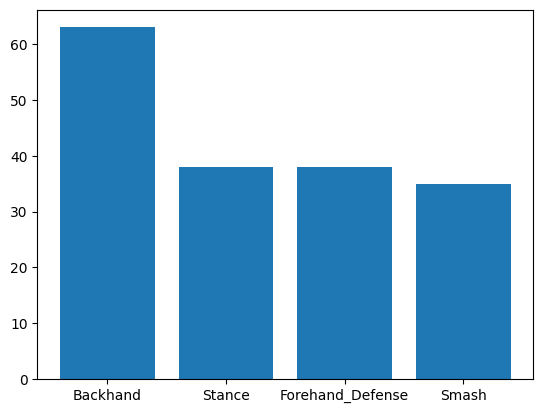

In [8]:
df1=df['Pose'].value_counts()
plt.bar(df1.index,df1.values)

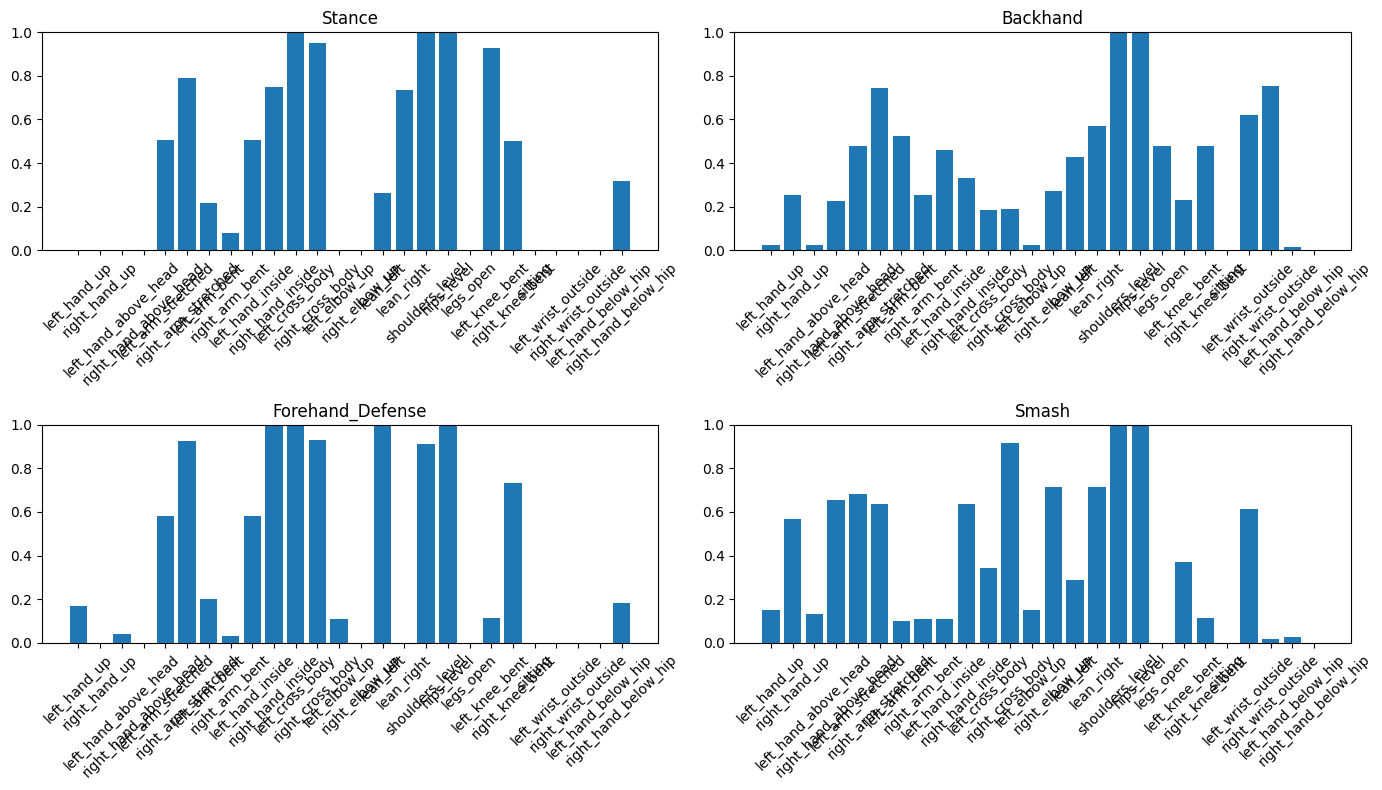

In [9]:
pose_avg = df.groupby('Pose').mean(numeric_only=True)
pose_avg.reset_index()
poses = ['Stance', 'Backhand', 'Forehand_Defense', 'Smash']
selected = pose_avg.loc[poses]

y_min = selected.values.min()
y_max = selected.values.max()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, pose in enumerate(poses):
    axes[i].bar(selected.columns, selected.loc[pose])
    
    axes[i].set_title(pose)
    axes[i].tick_params(axis='x', rotation=45)
    
    # 👇 same Y scale
    axes[i].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder
labe=LabelEncoder()
df['Pose']=labe.fit_transform(df['Pose'])

In [11]:
x=df.iloc[:,:-1].values
x

array([[0.        , 0.        , 0.        , ..., 0.02631579, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00069252, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00071075, 0.        ,
        0.        ],
       ...,
       [0.13843067, 0.55378547, 0.12168426, ..., 0.01727817, 0.0229368 ,
        0.        ],
       [0.14238583, 0.55292309, 0.12516095, ..., 0.01777183, 0.02359214,
        0.        ],
       [0.146454  , 0.55237569, 0.12873698, ..., 0.0182796 , 0.0242662 ,
        0.        ]])

In [12]:
y=df.iloc[:,-1].values
y

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

In [15]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

In [16]:
ann=Sequential()
#input layer
ann.add(Dense(units=64,activation='relu',input_dim=26))
#hiden layer
ann.add(Dense(units=32,activation='relu'))

#output layer
ann.add(Dense(4,activation='softmax'))

c:\Users\sreer\OneDrive\Desktop\Luminar\6.DeepLearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
#compile
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [18]:
ann.fit(x_train,y_train,epochs=100,batch_size=10) 

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4711 - loss: 1.1573
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9008 - loss: 0.7132
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.4647 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.2953
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.1822 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1101 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0713 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0475 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0346 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0261 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0205 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - a

In [19]:
ann.evaluate(x_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 1.7512e-04 


[0.000175121080246754, 1.0]

In [20]:
print(x_train.shape)

(121, 26)


In [23]:
# import joblib

joblib.dump(ann,'banminton_pose_model_ann.pkl')
joblib.dump(scale, "scaler.pkl")

['scaler.pkl']